# Xylella in an olive grove - Part 2: can felling stop it?

When *Xylella* is found, EU rules fell the infected tree and every host plant within a set
radius. Part 1 showed the outbreak sits on a sharp threshold. This part asks the policy
question directly, on a 180 m grove of 1,156 trees: **which felling radius, with which
speed of detection, leaves the most healthy trees standing?**

The score is healthy trees after five years - not infections. Felling a tree prevents its
infection only by removing it.

In [1]:
import sys, pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import figstyle
figstyle.apply()
from olive_model import OliveGrove, run_ensemble

grid_results = pickle.load(open('results/felling_grid.pkl', 'rb'))
unmanaged = pickle.load(open('results/unmanaged_big_grove.pkl', 'rb'))
GROVE = dict(width=180, height=180, sampling_rate=0.001, time_steps_per_day=30)

## How far does an infection jump?

Every infection in the unmanaged runs is logged with the tree it came from. The distance
between source and target is the reach a felling radius has to beat; the time between
the source's infection and the target's is the race detection has to win.

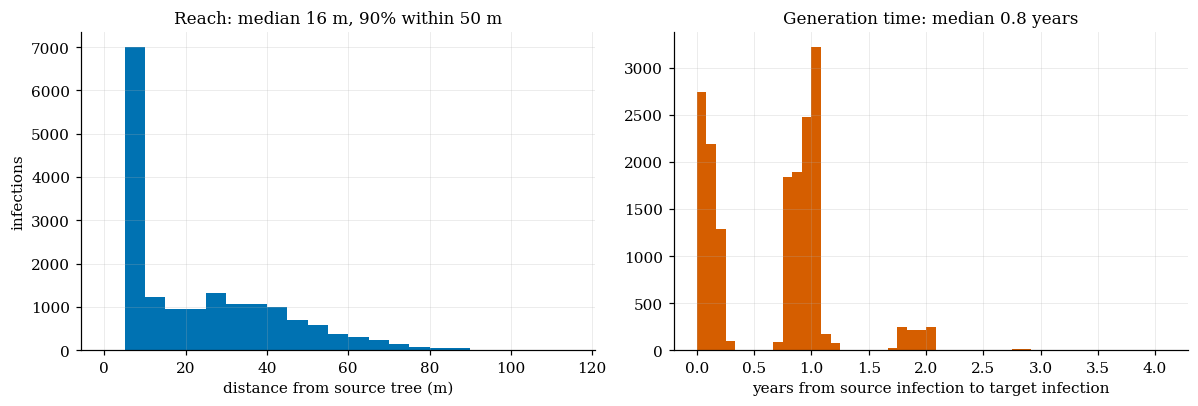

17073 logged infections; symptoms appear ~2 years after infection


In [2]:
dist, gen = [], []
for run in unmanaged:
    centres, inf_day = run['tree_centres'], run['infection_day']
    for day, src, tgt in run['log']:
        if src >= 0:
            dist.append(np.hypot(*(centres[src] - centres[tgt])))
            gen.append(inf_day[tgt] - inf_day[src])
dist, gen = np.array(dist), np.array(gen)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(dist, bins=np.arange(0, 120, 5), color=figstyle.PALETTE[0])
axes[0].set_xlabel('distance from source tree (m)')
axes[0].set_ylabel('infections')
axes[0].set_title(f'Reach: median {np.median(dist):.0f} m, 90% within {np.percentile(dist, 90):.0f} m')
axes[1].hist(gen / 365, bins=np.arange(0, 4.1, 1 / 12), color=figstyle.PALETTE[1])
axes[1].set_xlabel('years from source infection to target infection')
axes[1].set_title(f'Generation time: median {np.median(gen) / 365:.1f} years')
fig.tight_layout()
figstyle.save(fig, 'figures/fig5_kernel')
plt.show()
print(f"{len(dist)} logged infections; symptoms appear ~2 years after infection")

Most jumps are short, but a generation takes about a year - while symptoms take two. By
the time a tree looks ill, it has usually already passed the infection on, and the trees
it infected have started passing it on too.

## The felling grid

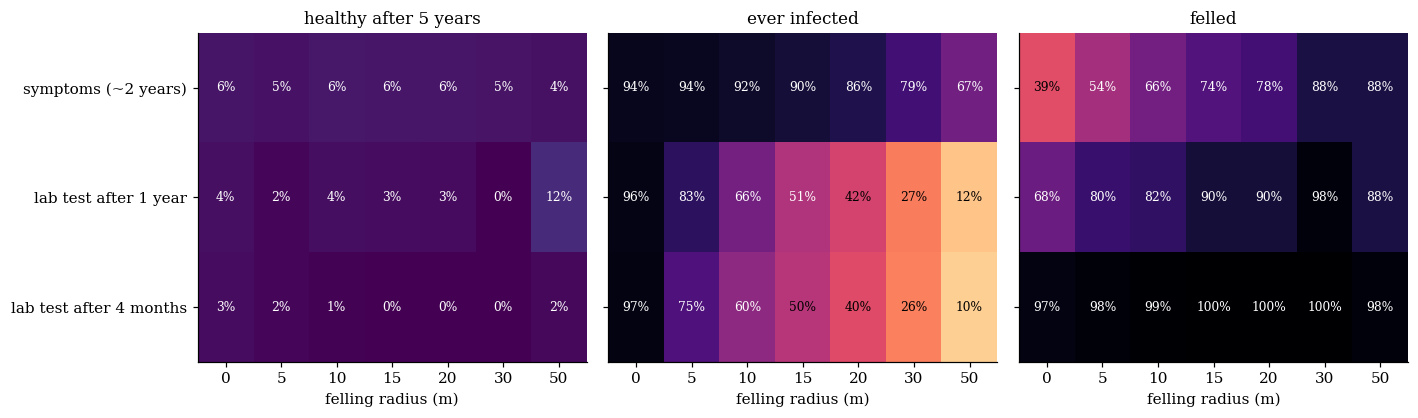

In [3]:
radii = grid_results['radii']
labels = list(grid_results['detection'])
healthy = np.array([[np.median([x['healthy'] for x in grid_results['grid'][(lab, r)]]) for r in radii] for lab in labels])
infected = np.array([[np.median([x['ever_infected'] for x in grid_results['grid'][(lab, r)]]) for r in radii] for lab in labels])
felled = np.array([[np.median([x['felled'] for x in grid_results['grid'][(lab, r)]]) for r in radii] for lab in labels])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), sharey=True)
for ax, data, title in zip(axes, [healthy, infected, felled], ['healthy after 5 years', 'ever infected', 'felled']):
    im = ax.imshow(data, cmap='viridis' if title.startswith('healthy') else 'magma_r', vmin=0, vmax=1, aspect='auto')
    for i in range(len(labels)):
        for j in range(len(radii)):
            ax.text(j, i, f"{data[i, j]:.0%}", ha='center', va='center', fontsize=8,
                    color='white' if (data[i, j] < 0.5) == title.startswith('healthy') else 'black')
    ax.set_xticks(range(len(radii)))
    ax.set_xticklabels(radii)
    ax.set_xlabel('felling radius (m)')
    ax.set_title(title)
    ax.grid(False)
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
fig.tight_layout()
figstyle.save(fig, 'figures/fig6_felling_grid')
plt.show()

**At the paper's settings, felling cannot win.** Wider radii and faster detection cut the
number of trees that get infected - from over 90% to about 10% - but only by felling
almost everything. Healthy trees left after five years stay in single figures in nearly
every combination. The disease is so far above its threshold (Part 1: a carrier on a tree
is near-certain to infect it) that by the time felling catches it, it has already moved.

That matches what happened in Apulia, where felling did not stop the spread and policy
moved from eradication to containment.

## Felling plus fewer spittlebug contacts

Part 1 found that outbreaks die out when the chance of infection per visit falls below
roughly 16-29%. Vector control - clearing the grass where spittlebugs breed, insecticide
in spring - pushes transmission down. Does felling then tip it over the edge?

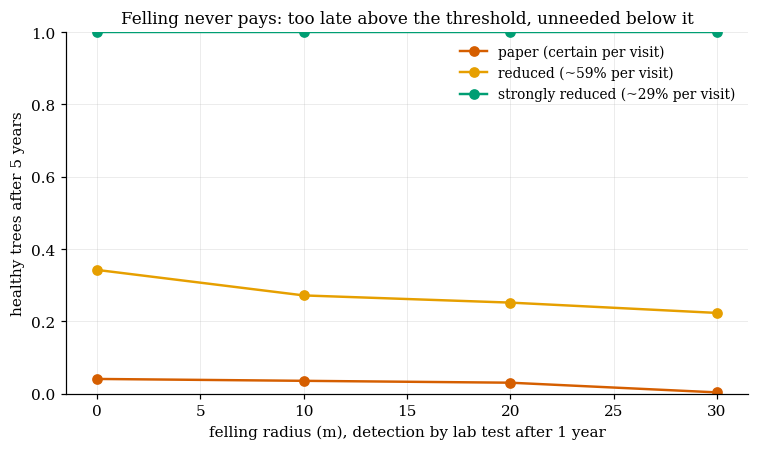

paper (certain per visit)          r= 0 m: healthy 4%
paper (certain per visit)          r=10 m: healthy 4%
paper (certain per visit)          r=20 m: healthy 3%
paper (certain per visit)          r=30 m: healthy 0%
reduced (~59% per visit)           r= 0 m: healthy 34%
reduced (~59% per visit)           r=10 m: healthy 27%
reduced (~59% per visit)           r=20 m: healthy 25%
reduced (~59% per visit)           r=30 m: healthy 22%
strongly reduced (~29% per visit)  r= 0 m: healthy 100%
strongly reduced (~29% per visit)  r=10 m: healthy 100%
strongly reduced (~29% per visit)  r=20 m: healthy 100%
strongly reduced (~29% per visit)  r=30 m: healthy 100%


In [4]:
levels = {'paper (certain per visit)': 1.0, 'reduced (~59% per visit)': 0.002, 'strongly reduced (~29% per visit)': 0.0006}
radii_vc = [0, 10, 20, 30]
vc = {}
for name, susceptibility in levels.items():
    for r in radii_vc:
        runs = run_ensemble(365 * 5, range(6), tree_susceptibility=susceptibility,
                            felling_radius=r, detection_delay=365, **GROVE)
        vc[(name, r)] = np.median([x['S'][-1] for x in runs])

fig, ax = plt.subplots(figsize=(7, 4.2))
for (name, _), colour in zip(levels.items(), [figstyle.PALETTE[1], figstyle.PALETTE[4], figstyle.PALETTE[2]]):
    ax.plot(radii_vc, [vc[(name, r)] for r in radii_vc], 'o-', color=colour, label=name)
ax.set_xlabel('felling radius (m), detection by lab test after 1 year')
ax.set_ylabel('healthy trees after 5 years')
ax.set_ylim(0, 1)
ax.set_title('Felling never pays: too late above the threshold, unneeded below it')
ax.legend()
fig.tight_layout()
figstyle.save(fig, 'figures/fig7_vector_control')
plt.show()
for (name, r), v in vc.items():
    print(f"{name:34s} r={r:2d} m: healthy {v:.0%}")

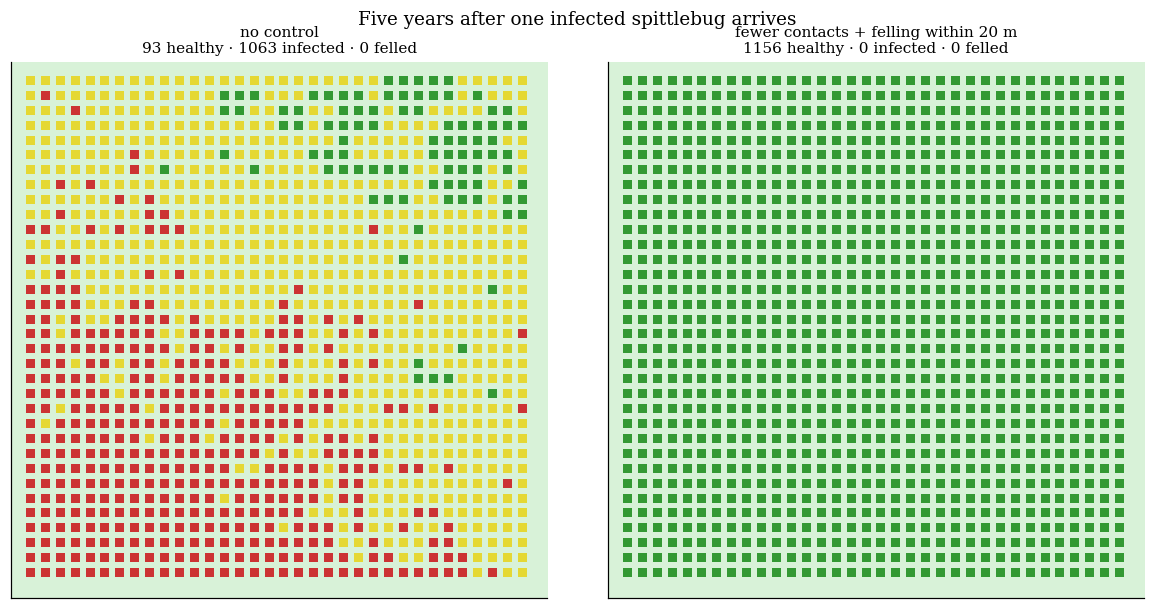

In [5]:
#the hero: one grove, felled as the disease advances
g = OliveGrove(seed=3, felling_radius=20, detection_delay=365, tree_susceptibility=0.0006, **GROVE).run(365 * 5)
u = OliveGrove(seed=3, **GROVE).run(365 * 5)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, grove, title in zip(axes, [u, g], ['no control', 'fewer contacts + felling within 20 m']):
    ax.imshow(grove.grove_image(), interpolation='nearest')
    counts = np.bincount(grove.tree_state, minlength=4)
    ax.set_title(f"{title}\n{counts[0]} healthy · {counts[1] + counts[2]} infected · {counts[3]} felled", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle('Five years after one infected spittlebug arrives', y=0.98)
fig.tight_layout()
figstyle.save(fig, 'figures/hero')
plt.show()

**In this model, felling never pays.** At the paper's transmission level no radius saves
the grove. Halfway to the threshold (~59% per visit), wider felling leaves *fewer* healthy
trees, not more - it removes healthy trees faster than it stops the disease. Below the
threshold (~29%), every outbreak dies out on its own, felled or not.

The lever that works is the one felling does not touch: **cutting the chance that a
spittlebug visit infects a tree** - vector control, which moves the grove across the
threshold. I expected felling and vector control to work together; the simulations say
vector control does the work. That is a model result, not policy advice, but it lines up
with the shift in Apulia from eradication towards vector control.